# Penentuan K manual

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import nnls

# Load data
df = pd.read_csv("user_features_for_AA.csv")

# Simpan Steam ID, Total_Games, dan Total_Achievements untuk nanti digabungkan
id_col = df["Steam ID"]
total_games = df["Total_Games"]
total_achievements = df["Total_Achievements"]

# Ambil semua kolom numerik kecuali Steam ID
feature_cols = [col for col in df.columns if col != 'Steam ID']
X = df[feature_cols].values

# Normalisasi data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Inisialisasi
n_samples, n_features = X_scaled.shape
n_archetypes = 4
np.random.seed(42)

# Random pilih k archetypes dari data sebagai awal
initial_indices = np.random.choice(n_samples, n_archetypes, replace=False)
Z = X_scaled[initial_indices]

# Alternating Minimization
max_iter = 100
tol = 1e-4
for iteration in range(max_iter):
    # Step 1: Update alpha (bobot tiap user terhadap archetype)
    A = np.zeros((n_samples, n_archetypes))
    for i in range(n_samples):
        A[i], _ = nnls(Z.T, X_scaled[i])

    # Step 2: Update Z (archetypes) dari alpha
    Z_new = np.zeros((n_archetypes, n_features))
    for j in range(n_archetypes):
        weights = A[:, j].reshape(-1, 1)
        if weights.sum() > 0:
            Z_new[j] = (weights * X_scaled).sum(axis=0) / weights.sum()
        else:
            Z_new[j] = Z[j]

    # Check konvergensi
    if np.linalg.norm(Z - Z_new) < tol:
        print(f"Konvergen di iterasi {iteration}")
        break
    Z = Z_new

# Susun hasil output sesuai format yang diinginkan
df_result = pd.DataFrame({
    "Steam ID": id_col,
    "Total_Games": total_games,
    "Total_Achievements": total_achievements
})

# Tambahkan bobot tiap archetype
for i in range(n_archetypes):
    df_result[f"Archetype_{i+1}_Weight"] = A[:, i]

# Simpan ke file
df_result.to_csv("archetypal_segments_k4.csv", index=False)
print("✅ Output akhir disimpan ke archetypal_segments_k4.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'user_features_for_AA.csv'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import nnls

# Cell 1: Load preprocessed feature matrix
df = pd.read_csv("user_features_for_AA.csv")
steam_ids = df["Steam ID"]
total_games = df["Total_Games"]
total_achievements = df["Total_Achievements"]

# Cell 2: Prepare feature matrix X (all numeric columns except Steam ID)
feature_cols = [c for c in df.columns if c != "Steam ID"]
X = df[feature_cols].values

# Cell 3: Normalize features to [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Cell 4: Initialize Archetypal Analysis parameters
n_samples, n_features = X_scaled.shape
n_archetypes = 4
np.random.seed(42)

# pick initial archetypes randomly from data points
initial_indices = np.random.choice(n_samples, n_archetypes, replace=False)
Z = X_scaled[initial_indices, :].copy()

# Cell 5: Alternating minimization to estimate archetypes Z and weights A
max_iter = 100
tol = 1e-4
for iteration in range(max_iter):
    # 1) estimate A via non‑negative least squares for each sample
    A = np.zeros((n_samples, n_archetypes))
    for i in range(n_samples):
        A[i, :], _ = nnls(Z.T, X_scaled[i, :])

    # 2) update Z as weighted average of samples
    Z_new = np.zeros_like(Z)
    for j in range(n_archetypes):
        w = A[:, j].reshape(-1, 1)  # weights for archetype j
        if w.sum() > 0:
            Z_new[j, :] = (w * X_scaled).sum(axis=0) / w.sum()
        else:
            Z_new[j, :] = Z[j, :]
    # check convergence
    if np.linalg.norm(Z - Z_new) < tol:
        print(f"Converged at iteration {iteration}")
        Z = Z_new
        break
    Z = Z_new

# Cell 6: Normalize rows of A so each sums to 1 (convex combination)
A_norm = A / A.sum(axis=1, keepdims=True)

# Cell 7: Build result dataframe
df_result = pd.DataFrame({
    "Steam ID": steam_ids,
    "Total_Games": total_games,
    "Total_Achievements": total_achievements
})

# add normalized archetype weights (1-based naming)
for k in range(n_archetypes):
    df_result[f"Archetype_{k+1}_Weight"] = A_norm[:, k]

# Cell 8: Save to CSV
df_result.to_csv("archetypal_segments_k4_normalized.csv", index=False)
print("✅ Saved normalized archetype weights to 'archetypal_segments_k4_normalized.csv'")


Converged at iteration 46
✅ Saved normalized archetype weights to 'archetypal_segments_k4_normalized.csv'


# Cari nilai minimal RE (loop)

K=2, RE=12.2782
K=3, RE=11.6008
K=4, RE=10.9168
K=5, RE=10.5072
K=6, RE=10.1141
K=7, RE=9.6493
K=8, RE=9.1806
K=9, RE=8.9024
K=10, RE=8.5777

👉 Best K (min RE) = 10


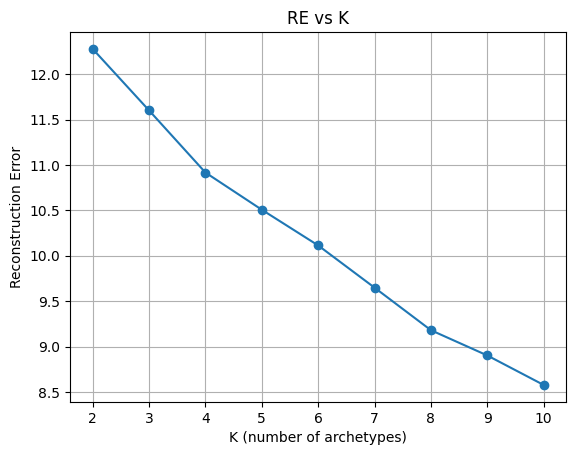

✅ Saved to 'archetypal_segments_normalized_bestK.csv' using K=10


In [ ]:
# Cell 1: Load preprocessed feature matrix
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import nnls

df = pd.read_csv("user_features_for_AA.csv")
steam_ids = df["Steam ID"]
total_games = df["Total_Games"]
total_achievements = df["Total_Achievements"]

# Cell 2: Prepare feature matrix X (all numeric columns except Steam ID)
feature_cols = [c for c in df.columns if c != "Steam ID"]
X = df[feature_cols].values

# Cell 3: Normalize features to [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Cell 4′: Evaluate Reconstruction Error for K=2…10 and pick best K
re_errors = []
Ks = list(range(2, 11))
n_samples, n_features = X_scaled.shape

for K in Ks:
    # initialize Z
    np.random.seed(42)
    init_idx = np.random.choice(n_samples, K, replace=False)
    Z = X_scaled[init_idx].copy()
    # alternating minimization
    for _ in range(100):
        A = np.zeros((n_samples, K))
        for i in range(n_samples):
            A[i], _ = nnls(Z.T, X_scaled[i])
        Z_new = np.zeros_like(Z)
        for j in range(K):
            w = A[:, j].reshape(-1,1)
            if w.sum()>0:
                Z_new[j] = (w * X_scaled).sum(axis=0) / w.sum()
            else:
                Z_new[j] = Z[j]
        if np.linalg.norm(Z-Z_new) < 1e-4:
            Z = Z_new
            break
        Z = Z_new
    # normalize A rows
    A_norm = A / A.sum(axis=1, keepdims=True)
    # compute RE
    X_hat = A_norm @ Z
    re = np.linalg.norm(X_scaled - X_hat)
    re_errors.append(re)
    print(f"K={K}, RE={re:.4f}")

best_K = Ks[int(np.argmin(re_errors))]
print(f"\n👉 Best K (min RE) = {best_K}")

# (opsional plot)
import matplotlib.pyplot as plt
plt.plot(Ks, re_errors, 'o-')
plt.xlabel("K (number of archetypes)")
plt.ylabel("Reconstruction Error")
plt.title("RE vs K")
plt.grid(True)
plt.show()

# Cell 5: Run AA with best_K
n_archetypes = best_K
np.random.seed(42)
init_idx = np.random.choice(n_samples, n_archetypes, replace=False)
Z = X_scaled[init_idx].copy()
for _ in range(100):
    A = np.zeros((n_samples, n_archetypes))
    for i in range(n_samples):
        A[i], _ = nnls(Z.T, X_scaled[i])
    Z_new = np.zeros_like(Z)
    for j in range(n_archetypes):
        w = A[:, j].reshape(-1,1)
        if w.sum()>0:
            Z_new[j] = (w * X_scaled).sum(axis=0) / w.sum()
        else:
            Z_new[j] = Z[j]
    if np.linalg.norm(Z-Z_new) < 1e-4:
        Z = Z_new
        break
    Z = Z_new

# Cell 6: Normalize rows of A so each sums to 1
A_norm = A / A.sum(axis=1, keepdims=True)

# Cell 7: Build and save result dataframe
df_result = pd.DataFrame({
    "Steam ID": steam_ids,
    "Total_Games": total_games,
    "Total_Achievements": total_achievements
})
for k in range(n_archetypes):
    df_result[f"Archetype_{k+1}_Weight"] = A_norm[:, k]

df_result.to_csv("archetypal_segments_normalized_bestK.csv", index=False)
print(f"✅ Saved to 'archetypal_segments_normalized_bestK.csv' using K={best_K}")



# Pakai Elbow

K=1, RSS=122.2969
K=2, RSS=105.7079
K=3, RSS=93.6254
K=4, RSS=84.9542
K=5, RSS=77.4633
K=6, RSS=71.0252
K=7, RSS=64.9050
K=8, RSS=59.9402
K=9, RSS=56.7080
K=10, RSS=51.9666
K=11, RSS=48.8470
K=12, RSS=45.1749
K=13, RSS=43.8059
K=14, RSS=40.8218
K=15, RSS=38.2564


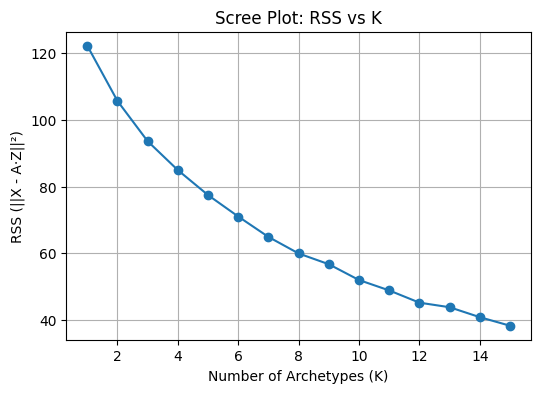

Elbow detected at K = 7
Using K = 7 for final analysis
✅ Saved to 'archetypal_segments_elbowK.csv'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import nnls
import matplotlib.pyplot as plt
from kneed import KneeLocator

# ---------------------------
# Cell 1: Load & Prepare Data
# ---------------------------
df = pd.read_csv("user_features_for_AA.csv")
steam_ids = df["Steam ID"]
total_games = df["Total_Games"]
total_achievements = df["Total_Achievements"]

# select all feature columns (exclude Steam ID)
feature_cols = [c for c in df.columns if c != "Steam ID"]
X = df[feature_cols].values

# normalize to [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------
# Cell 2: Define function to compute RE
# ---------------------------------------
def compute_re(X, K, max_iter=100, tol=1e-4):
    """
    Run AA with K archetypes (NNLS + alternating minimization)
    and return reconstruction error RE = ||X - A @ Z||_F.
    """
    n, d = X.shape
    rng = np.random.RandomState(42)
    replace_flag = (K > n)
    Z = X[rng.choice(n, K, replace=replace_flag)].copy()
    for _ in range(max_iter):
        # A-step: solve NNLS for each sample
        A = np.zeros((n, K))
        for i in range(n):
            A[i], _ = nnls(Z.T, X[i])
        # Z-step: update archetypes
        Z_new = np.zeros_like(Z)
        for j in range(K):
            w = A[:, j][:, None]
            if w.sum() > 0:
                Z_new[j] = (w * X).sum(axis=0) / w.sum()
            else:
                Z_new[j] = Z[j]
        if np.linalg.norm(Z - Z_new) < tol:
            Z = Z_new
            break
        Z = Z_new
    # normalize rows of A to sum=1
    A_norm = A / A.sum(axis=1, keepdims=True)
    # reconstruction
    X_hat = A_norm @ Z
    return np.linalg.norm(X - X_hat)

# --------------------------------------------------
# Cell 3: Scree Plot (RSS vs K) & Elbow Determination
# --------------------------------------------------
Ks = list(range(1, 16))   # test K = 1..15
rss = []
for K in Ks:
    re = compute_re(X_scaled, K)
    rss.append(re**2)
    print(f"K={K}, RSS={rss[-1]:.4f}")

# Plot Scree
plt.figure(figsize=(6,4))
plt.plot(Ks, rss, marker='o')
plt.xlabel("Number of Archetypes (K)")
plt.ylabel("RSS (||X - A·Z||²)")
plt.title("Scree Plot: RSS vs K")
plt.grid(True)
plt.show()

# automatic elbow detection
kl = KneeLocator(Ks, rss, curve='convex', direction='decreasing')
elbow_k = kl.elbow
print(f"Elbow detected at K = {elbow_k}")

# fallback if elbow not found
best_K = elbow_k or 4
print(f"Using K = {best_K} for final analysis")

# ----------------------------------------
# Cell 4: Final Archetypal Analysis (K=best_K)
# ----------------------------------------
n, d = X_scaled.shape
rng = np.random.RandomState(42)
replace_flag = (best_K > n)
Z = X_scaled[rng.choice(n, best_K, replace=replace_flag)].copy()
for _ in range(100):
    A = np.zeros((n, best_K))
    for i in range(n):
        A[i], _ = nnls(Z.T, X_scaled[i])
    Z_new = np.zeros_like(Z)
    for j in range(best_K):
        w = A[:, j][:, None]
        if w.sum() > 0:
            Z_new[j] = (w * X_scaled).sum(axis=0) / w.sum()
        else:
            Z_new[j] = Z[j]
    if np.linalg.norm(Z - Z_new) < 1e-4:
        Z = Z_new
        break
    Z = Z_new

# normalize final A
A_norm = A / A.sum(axis=1, keepdims=True)

# ---------------------------------
# Cell 5: Build & Save Final Result
# ---------------------------------
df_result = pd.DataFrame({
    "Steam ID": steam_ids,
    "Total_Games": total_games,
    "Total_Achievements": total_achievements
})
for k in range(best_K):
    df_result[f"Archetype_{k+1}_Weight"] = A_norm[:, k]

df_result.to_csv("archetypal_segments_elbowK.csv", index=False)
print("✅ Saved to 'archetypal_segments_elbowK.csv'")


/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


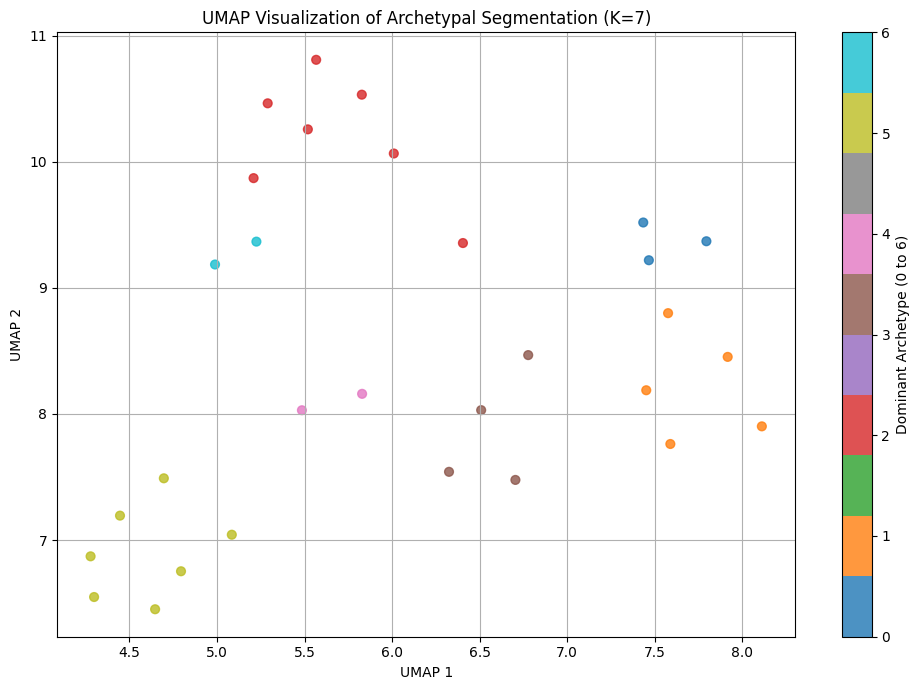

In [ ]:
# 1. Import Library
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import nnls
import matplotlib.pyplot as plt
import umap

# 2. Load Data & Siapkan Fitur
df_feats = pd.read_csv("user_features_for_AA.csv")
steam_ids    = df_feats["Steam ID"]
total_games  = df_feats["Total_Games"]
total_achiev = df_feats["Total_Achievements"]

# Buat matriks X dan normalisasi
X = df_feats.drop(columns=["Steam ID"]).values
X_scaled = MinMaxScaler().fit_transform(X)

# 3. Final Archetypal Analysis (K = 7)
best_K = 7
n, d   = X_scaled.shape
rng    = np.random.RandomState(42)
Z      = X_scaled[rng.choice(n, best_K, replace=(best_K > n))].copy()

for _ in range(100):
    A = np.zeros((n, best_K))
    for i in range(n):
        A[i], _ = nnls(Z.T, X_scaled[i])
    Z_new = np.zeros_like(Z)
    for j in range(best_K):
        w = A[:, j][:, None]
        Z_new[j] = (w * X_scaled).sum(axis=0)/w.sum() if w.sum() > 0 else Z[j]
    if np.linalg.norm(Z - Z_new) < 1e-4:
        Z = Z_new
        break
    Z = Z_new

# Hitung bobot partisipasi
A_norm = A / A.sum(axis=1, keepdims=True)

# 4. Visualisasi UMAP
dominant_archetypes = np.argmax(A_norm, axis=1)
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(A_norm)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1],
                      c=dominant_archetypes, cmap='tab10', s=40, alpha=0.8)

plt.title("UMAP Visualization of Archetypal Segmentation (K=7)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Dominant Archetype (0 to 6)")
plt.grid(True)
plt.tight_layout()
plt.savefig("archetype_umap_k7.png", dpi=300)
plt.show()


In [ ]:
output_json_path = "segmentation_result.json"
df_out.to_json(output_json_path, orient="records", force_ascii=False, indent=2)

print(f"✅ Saved JSON output to '{output_json_path}'")

✅ Saved JSON output to 'segmentation_result.json'


In [ ]:
membership = []
threshold = 0.40

for k in range(best_K):
    col = f"Archetype_{k+1}_Weight"
    # pilih Steam ID dengan bobot ≥ threshold
    ids = df_out.loc[df_out[col] >= threshold, "Steam ID"].tolist()
    membership.append({
        "Archetype": k+1,
        "Member_Steam_IDs": ids
    })

membership_df = pd.DataFrame(membership)

# Simpan ke CSV
membership_df.to_csv("archetype_membership.csv", index=False)

print("✅ Saved archetype membership to 'archetype_membership.csv'")


✅ Saved archetype membership to 'archetype_membership.csv'


# FIX

Selected best K: 5


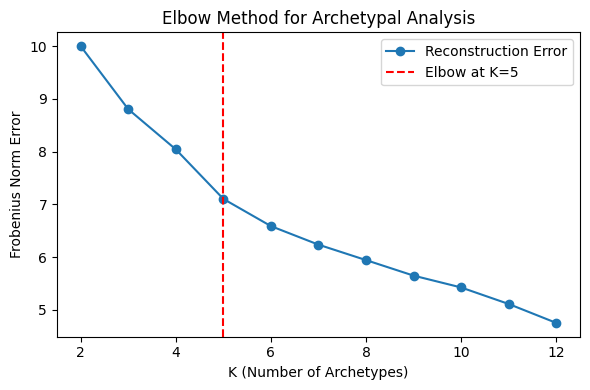

/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


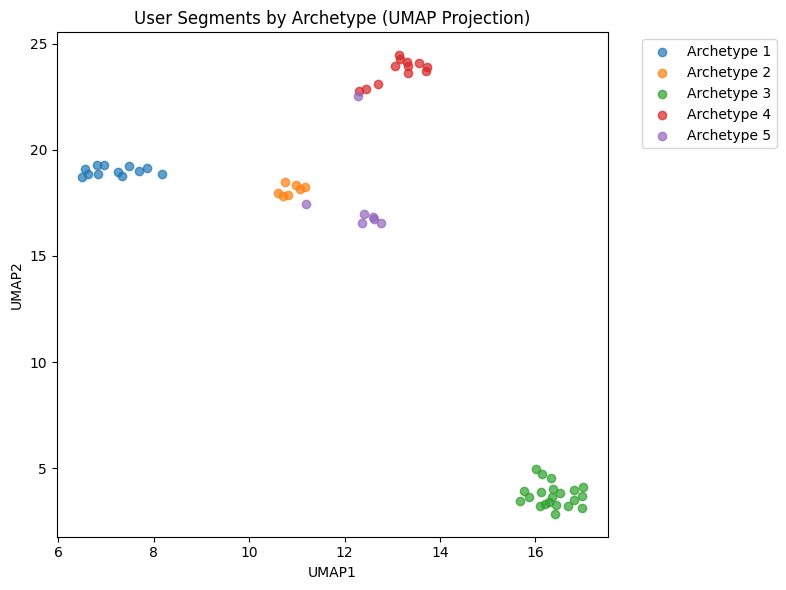

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import nnls
from collections import Counter
import matplotlib.pyplot as plt
import umap
from kneed import KneeLocator

# ===================================
# 1) Load & Prepare Data for AA
# ===================================
df_feats = pd.read_csv("user_features_for_AA_v2.csv", dtype={"steam_id": str})
steam_ids = df_feats["steam_id"].tolist()

# Keep basics for later
total_games = df_feats.set_index("steam_id")["total_game"].to_dict()
total_playtime = df_feats.set_index("steam_id")["total_playtime"].to_dict()  # ✅ tambahan
total_achievements = df_feats.set_index("steam_id")["total_achievement"].to_dict()

# Build and scale feature matrix X
feature_cols = [c for c in df_feats.columns if c != "steam_id"]
X = df_feats[feature_cols].values
X_scaled = MinMaxScaler().fit_transform(X)

# ===================================
# 2) Load Raw Segmentation & Features
# ===================================
df_raw = pd.read_csv("transformation_segmentation_v4.csv", dtype={"Steam ID": str})
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
df_raw = df_raw[df_raw["steam_id"].isin(steam_ids)]

dominant_topic = df_raw.groupby("steam_id")["topic_dominan"].first().to_dict()

tmp = df_raw.groupby("steam_id")["genre_dominan"] \
            .apply(lambda xs: [g for g, _ in Counter(xs).most_common(3)])
top3_genres = {
    sid: tmp.get(sid, [])[:3] + [np.nan] * (3 - len(tmp.get(sid, [])))
    for sid in steam_ids
}

# ===================================
# 3) Archetypal Analysis Function
# ====================================
def compute_normed_A(X, K, max_iter=100, tol=1e-4):
    n, d = X.shape
    rng = np.random.RandomState(42)
    # Initialize archetypes randomly
    Z = X[rng.choice(n, K, replace=(K > n))].copy()

    for _ in range(max_iter):
        # Solve for weights A via non-negative least squares
        A = np.zeros((n, K))
        for i in range(n):
            A[i], _ = nnls(Z.T, X[i])

        # Update archetypes Z
        Z_new = np.zeros_like(Z)
        for j in range(K):
            w = A[:, j][:, None]
            if w.sum() > 0:
                Z_new[j] = (w * X).sum(axis=0) / w.sum()
            else:
                Z_new[j] = Z[j]

        # Check convergence
        if np.linalg.norm(Z - Z_new) < tol:
            break
        Z = Z_new

    # Normalize rows of A to sum to 1
    A_norm = A / A.sum(axis=1, keepdims=True)
    return A_norm, Z

# ===================================
# 4) Determine Best K via Elbow Method
# ====================================
min_K, max_K = 2, 12
Ks = list(range(min_K, max_K + 1))
errors = []

for K in Ks:
    A_norm_k, Z_k = compute_normed_A(X_scaled, K)
    # Reconstruction error (Frobenius norm)
    X_recon = A_norm_k.dot(Z_k)
    errors.append(np.linalg.norm(X_scaled - X_recon, 'fro'))

# Use KneeLocator to find elbow point
kl = KneeLocator(Ks, errors, curve='convex', direction='decreasing')
best_K = kl.elbow or Ks[np.argmin(errors)]
print(f"Selected best K: {best_K}")

# Plot the error curve with elbow marked
plt.figure(figsize=(6,4))
plt.plot(Ks, errors, 'o-', label='Reconstruction Error')
if kl.elbow:
    plt.axvline(kl.elbow, color='red', linestyle='--', label=f'Elbow at K={kl.elbow}')
plt.xlabel('K (Number of Archetypes)')
plt.ylabel('Frobenius Norm Error')
plt.title('Elbow Method for Archetypal Analysis')
plt.legend()
plt.tight_layout()
plt.show()

# ===================================
# 5) Compute Final AA with Best K
# ====================================
A_norm, Z = compute_normed_A(X_scaled, best_K)

# ===================================
# 6) Save Archetype Membership (Dominant Only)
# ====================================
dominant_archetypes = np.argmax(A_norm, axis=1) + 1  # 1-based index

# Build dictionary archetype -> list of steam_ids
dominant_membership = {f"archetype_{k+1}": [] for k in range(best_K)}
for sid, arc in zip(steam_ids, dominant_archetypes):
    dominant_membership[f"archetype_{arc}"].append(sid)

# Pad lists to equal length
max_len = max(len(v) for v in dominant_membership.values())
for k in dominant_membership:
    dominant_membership[k] += [np.nan] * (max_len - len(dominant_membership[k]))

# Save to CSV
pd.DataFrame(dominant_membership).to_csv("archetype_membership.csv", index=False)

# ===================================
# 7) Save Segmentation per User
# ====================================
rows = []
for idx, sid in enumerate(steam_ids):
    t1, t2, t3 = top3_genres[sid]
    row = {
        "steam_id": sid,
        "total_game": total_games[sid],
        "total_playtime": total_playtime[sid],  # ✅ baris tambahan
        "total_achievement": total_achievements[sid],
        "dominant_topic": dominant_topic.get(sid, np.nan),
        "top_1_genre": t1,
        "top_2_genre": t2,
        "top_3_genre": t3
    }
    # Add archetype weights
    for k in range(best_K):
        row[f"archetype_{k+1}_weight"] = A_norm[idx, k]
    rows.append(row)

# Create DataFrame and save
pd.DataFrame(rows).to_csv("archetypal_segments_elbowK_top3.csv", index=False)

# ===================================
# 8) UMAP Visualization of Archetype Segments
# ====================================
reducer = umap.UMAP(n_components=2, random_state=42)
coords_umap = reducer.fit_transform(A_norm)
dominant_arc = np.argmax(A_norm, axis=1) + 1

plt.figure(figsize=(8,6))
for k in range(1, best_K + 1):
    mask = dominant_arc == k
    plt.scatter(
        coords_umap[mask, 0],
        coords_umap[mask, 1],
        label=f"Archetype {k}",
        alpha=0.7
    )
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("User Segments by Archetype (UMAP Projection)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score
labels = np.argmax(A_norm, axis=1)
print("Silhouette:", silhouette_score(A_norm, labels))


Silhouette: 0.7823373819715174


In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
# 5) Compute Final AA with Best K
A_norm, Z = compute_normed_A(X_scaled, best_K)

# Hitung Reconstruction Error (RE) seperti sebelumnya
X_recon = A_norm.dot(Z)
recon_error = np.linalg.norm(X_scaled - X_recon, 'fro')
print(f"Reconstruction Error: {recon_error:.4f}")

# Tambahkan Silhouette Score
# Tetapkan label segmen berdasarkan arketipe dominan
labels = np.argmax(A_norm, axis=1)
sil_score = silhouette_score(A_norm, labels)
print(f"Silhouette Score (on A_norm): {sil_score:.4f}")


Reconstruction Error: 7.1043
Silhouette Score (on A_norm): 0.7823


No sensitive column detected: created proxy 'playtime_median_group' (median split).
Sensitive groups and counts:
0    30
1    29
Name: count, dtype: int64
Running AA for K=2 ...
K=2: RE=9.9991, SS=0.8720403294225343, EV=0.37839471329896746, MMD=-0.010827860401344758, LS=0.5287878787878787
Running AA for K=3 ...
K=3: RE=8.8047, SS=0.8085542983651669, EV=0.5180267986636813, MMD=-0.01079367287666999, LS=0.4242424242424242
Running AA for K=4 ...
K=4: RE=8.0432, SS=0.8034821294262277, EV=0.5977852638603676, MMD=-0.014590567249195496, LS=0.4590909090909091
Running AA for K=5 ...
K=5: RE=7.1043, SS=0.7823373819715174, EV=0.686210975612103, MMD=-0.0076801354402002975, LS=0.47575757575757577
Running AA for K=6 ...
K=6: RE=6.5888, SS=0.6959246934888896, EV=0.73009435438395, MMD=-0.002284623225333071, LS=0.5954545454545455
Running AA for K=7 ...
K=7: RE=6.2372, SS=0.7502501417479567, EV=0.7581362461877423, MMD=-0.0007442363695309151, LS=0.5424242424242424
Running AA for K=8 ...
K=8: RE=5.9446, SS

/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_mo

Perbandingan K tersimpan di aa_k_comparison_extended.csv
Selected best K: 5


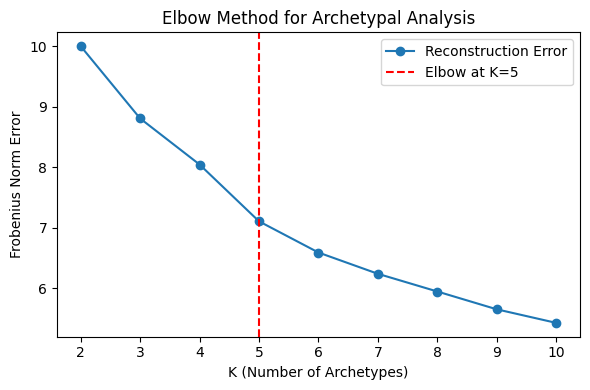

Final metrics for best_K= 5 :
 RE=7.1043, EV=0.686210975612103, SS=0.7823373819715174, MMD=-0.0076801354402002975, LS=0.47575757575757577


/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_mo

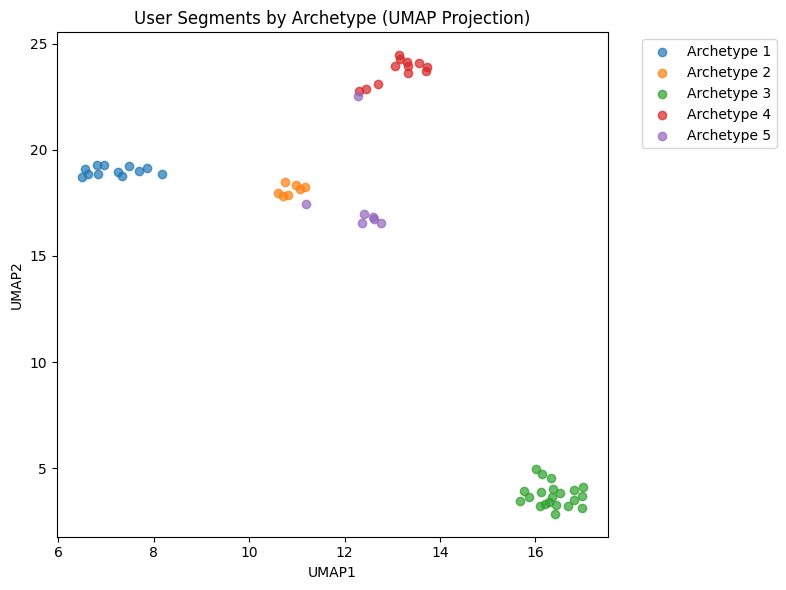

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from scipy.optimize import nnls
from collections import Counter
import matplotlib.pyplot as plt
import umap
from kneed import KneeLocator

# ===================================
# 1) Load & Prepare Data for AA
# ===================================
df_feats = pd.read_csv("user_features_for_AA_v2.csv", dtype={"steam_id": str})
steam_ids = df_feats["steam_id"].tolist()

# Keep basics for later (assume these columns exist)
total_games = df_feats.set_index("steam_id")["total_game"].to_dict()
total_playtime = df_feats.set_index("steam_id")["total_playtime"].to_dict()
total_achievements = df_feats.set_index("steam_id")["total_achievement"].to_dict()

# Build and scale feature matrix X (exclude steam_id)
feature_cols = [c for c in df_feats.columns if c != "steam_id"]
X = df_feats[feature_cols].values
X_scaled = MinMaxScaler().fit_transform(X)

# ===================================
# 2) Load Raw Segmentation & Features
# ===================================
df_raw = pd.read_csv("transformation_segmentation_v4.csv", dtype={"Steam ID": str})
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
df_raw = df_raw[df_raw["steam_id"].isin(steam_ids)]

# map dominant topic if available
if "topic_dominan" in df_raw.columns:
    dominant_topic = df_raw.groupby("steam_id")["topic_dominan"].first().to_dict()
else:
    dominant_topic = {}

tmp = df_raw.groupby("steam_id")["genre_dominan"] \
            .apply(lambda xs: [g for g, _ in Counter(xs).most_common(3)]) if "genre_dominan" in df_raw.columns else pd.Series()
top3_genres = {
    sid: (tmp.get(sid, [])[:3] + [np.nan] * (3 - len(tmp.get(sid, [])))) if sid in tmp.index else [np.nan, np.nan, np.nan]
    for sid in steam_ids
}

# ===================================
# 3) Sensitive attribute detection or proxy creation
# ===================================
# If you have a known sensitive column, set it here, e.g. sensitive_col = "gender"
sensitive_col = None  # <-- set to column name string to force using that column

_possible_names = ['sensitive', 'gender', 'sex', 'group', 'age_group', 'protected', 'race', 'ethnicity', 'dominant_topic']
found = None
if sensitive_col is None:
    for col in df_feats.columns:
        if col.lower() in _possible_names:
            found = col
            break
    if found is None:
        for col in df_raw.columns:
            if col.lower() in _possible_names:
                found = col
                break
    if found:
        sensitive_col = found

# If still None, create a proxy group (median split on total_playtime or total_game, or use dominant_topic)
if sensitive_col is None:
    if "total_playtime" in df_feats.columns:
        df_feats["playtime_median_group"] = (df_feats["total_playtime"] > df_feats["total_playtime"].median()).astype(int).astype(str)
        sensitive_col = "playtime_median_group"
        print("No sensitive column detected: created proxy 'playtime_median_group' (median split).")
    elif "total_game" in df_feats.columns:
        df_feats["total_game_median_group"] = (df_feats["total_game"] > df_feats["total_game"].median()).astype(int).astype(str)
        sensitive_col = "total_game_median_group"
        print("No sensitive column detected: created proxy 'total_game_median_group' (median split).")
    elif "topic_dominan" in df_raw.columns:
        tmp_map = df_raw.set_index("steam_id")["topic_dominan"].to_dict()
        df_feats["dominant_topic_proxy"] = df_feats["steam_id"].map(tmp_map).fillna("unknown").astype(str)
        sensitive_col = "dominant_topic_proxy"
        print("No sensitive column detected: created proxy 'dominant_topic_proxy' from df_raw.")
    else:
        sensitive_col = None
        print("Warning: no sensitive attribute found and no proxy could be created. MMD and LS will be skipped.")

# Build sensitive_array aligned to steam_ids order
if sensitive_col is not None:
    if sensitive_col in df_feats.columns:
        sens_map = df_feats.set_index("steam_id")[sensitive_col].to_dict()
        sensitive_array = np.array([sens_map.get(sid, np.nan) for sid in steam_ids], dtype=object)
    elif sensitive_col in df_raw.columns:
        sens_map = df_raw.set_index("steam_id")[sensitive_col].to_dict()
        sensitive_array = np.array([sens_map.get(sid, np.nan) for sid in steam_ids], dtype=object)
    else:
        sensitive_array = None
else:
    sensitive_array = None

# Print group counts for debugging
if sensitive_array is not None:
    counts = pd.Series(sensitive_array).fillna("nan").value_counts()
    print("Sensitive groups and counts:")
    print(counts)
    small = counts[counts < 2]
    if len(small) > 0:
        print("Warning: some groups have <2 samples (these groups will be ignored for pairwise MMD).")
else:
    print("sensitive_array is None -> MMD and Linear Separability will be skipped.")

# ===================================
# 4) Archetypal Analysis Function
# ====================================
def compute_normed_A(X, K, max_iter=100, tol=1e-4):
    n, d = X.shape
    rng = np.random.RandomState(42)
    Z = X[rng.choice(n, K, replace=(K > n))].copy()  # (K, d)

    for _ in range(max_iter):
        A = np.zeros((n, K))
        for i in range(n):
            # solve Z.T * a = X[i]  => use nnls for non-negative weights
            A[i], _ = nnls(Z.T, X[i])

        Z_new = np.zeros_like(Z)
        for j in range(K):
            w = A[:, j][:, None]  # (n,1)
            if w.sum() > 0:
                Z_new[j] = (w * X).sum(axis=0) / w.sum()
            else:
                Z_new[j] = Z[j]

        if np.linalg.norm(Z - Z_new) < tol:
            break
        Z = Z_new

    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    A_norm = A / row_sums
    return A_norm, Z

# ===================================
# 5) Helper metrics: EV, MMD, LS
# ====================================
def explained_variance_matrix(X_true, X_recon):
    num = np.sum((X_true - X_recon)**2)
    denom = np.sum((X_true - X_true.mean(axis=0))**2)
    if denom == 0:
        return np.nan
    ev = 1 - (num / denom)
    return float(ev)

def rbf_kernel_matrix(X, Y=None, gamma=None):
    if Y is None:
        Y = X
    XX = np.sum(X**2, axis=1)[:, None]
    YY = np.sum(Y**2, axis=1)[None, :]
    D2 = XX + YY - 2 * np.dot(X, Y.T)
    if gamma is None:
        dists = D2.flatten()
        dists = dists[dists > 0]
        if len(dists) == 0:
            gamma = 1.0
        else:
            med = np.median(dists)
            gamma = 1.0 / (2 * med) if med > 0 else 1.0
    K = np.exp(-gamma * D2)
    return K, gamma

def compute_mmd_rbf(X, Y, gamma=None):
    m = X.shape[0]; n = Y.shape[0]
    if m < 2 or n < 2:
        return np.nan
    Kxx, gamma = rbf_kernel_matrix(X, None, gamma)
    Kyy, _ = rbf_kernel_matrix(Y, None, gamma)
    Kxy, _ = rbf_kernel_matrix(X, Y, gamma)
    sum_kxx = (np.sum(Kxx) - np.trace(Kxx))
    sum_kyy = (np.sum(Kyy) - np.trace(Kyy))
    mmd = (sum_kxx / (m * (m - 1))) + (sum_kyy / (n * (n - 1))) - (2 * np.sum(Kxy) / (m * n))
    return float(mmd)

def average_pairwise_mmd(X_repr, sensitive_array):
    if sensitive_array is None:
        return np.nan
    mask_valid = ~pd.isna(sensitive_array)
    groups, inv = np.unique(sensitive_array[mask_valid], return_inverse=True)
    if len(groups) < 2:
        return np.nan
    mmds = []
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            Xi = X_repr[sensitive_array == groups[i]]
            Xj = X_repr[sensitive_array == groups[j]]
            if Xi.shape[0] < 2 or Xj.shape[0] < 2:
                continue
            m = compute_mmd_rbf(Xi, Xj, gamma=None)
            if not np.isnan(m):
                mmds.append(m)
    if len(mmds) == 0:
        return np.nan
    return float(np.mean(mmds))

def linear_separability_score(X_repr, sensitive_array, cv_folds=5):
    if sensitive_array is None:
        return np.nan
    mask = ~pd.isna(sensitive_array)
    y = sensitive_array[mask]
    Xsub = X_repr[mask]
    unique, counts = np.unique(y, return_counts=True)
    if len(unique) < 2:
        return np.nan
    min_count = np.min(counts)
    # stratified CV only possible if each class has at least 2 samples and n_splits >= 2
    n_splits = min(cv_folds, min_count) if min_count >= 2 else 1
    clf = LogisticRegression(max_iter=1000, multi_class='auto', solver='lbfgs')
    if n_splits >= 2:
        try:
            skf = StratifiedKFold(n_splits=n_splits)
            scores = cross_val_score(clf, Xsub, y, cv=skf, scoring='accuracy')
            return float(np.mean(scores))
        except Exception:
            pass
    # fallback: single train/test split
    try:
        Xtr, Xte, ytr, yte = train_test_split(Xsub, y, test_size=0.3, stratify=y, random_state=42)
        clf.fit(Xtr, ytr)
        acc = clf.score(Xte, yte)
        return float(acc)
    except Exception:
        return np.nan

# ===================================
# 6) Compare K from 2 to 10 and Save Extended Metrics
# ====================================
min_K, max_K = 2, 10
Ks = list(range(min_K, max_K + 1))
errors = []
results = []

for K in Ks:
    print(f"Running AA for K={K} ...")
    A_norm_k, Z_k = compute_normed_A(X_scaled, K)
    X_recon = A_norm_k.dot(Z_k)
    re_error = float(np.linalg.norm(X_scaled - X_recon, 'fro'))
    errors.append(re_error)
    try:
        labels = np.argmax(A_norm_k, axis=1)
        sil_score = float(silhouette_score(A_norm_k, labels))
    except Exception:
        sil_score = np.nan

    ev = explained_variance_matrix(X_scaled, X_recon)
    mmd_val = average_pairwise_mmd(A_norm_k, sensitive_array) if sensitive_array is not None else np.nan
    ls_val = linear_separability_score(A_norm_k, sensitive_array, cv_folds=5) if sensitive_array is not None else np.nan

    results.append({
        "K": K,
        "Reconstruction_Error": re_error,
        "Silhouette_Score": sil_score,
        "Explained_Variance": ev,
        "MMD": mmd_val,
        "Linear_Separability": ls_val
    })
    print(f"K={K}: RE={re_error:.4f}, SS={sil_score}, EV={ev}, MMD={mmd_val}, LS={ls_val}")

# Save extended comparison
df_results = pd.DataFrame(results)
df_results.to_csv("aa_k_comparison_extended.csv", index=False)
print("Perbandingan K tersimpan di aa_k_comparison_extended.csv")

# ===================================
# 7) Determine best_K via Elbow Method (RE)
# ====================================
kl = KneeLocator(Ks, [r["Reconstruction_Error"] for r in results], curve='convex', direction='decreasing')
best_K = kl.elbow or Ks[np.argmin([r["Reconstruction_Error"] for r in results])]
print(f"Selected best K: {best_K}")

plt.figure(figsize=(6,4))
plt.plot(Ks, [r["Reconstruction_Error"] for r in results], 'o-', label='Reconstruction Error')
if kl.elbow:
    plt.axvline(kl.elbow, color='red', linestyle='--', label=f'Elbow at K={kl.elbow}')
plt.xlabel('K (Number of Archetypes)')
plt.ylabel('Frobenius Norm Error')
plt.title('Elbow Method for Archetypal Analysis')
plt.legend()
plt.tight_layout()
plt.show()

# ===================================
# 8) Compute Final AA with Best K and Save Outputs
# ====================================
A_norm, Z = compute_normed_A(X_scaled, best_K)

# final metrics
X_recon_final = A_norm.dot(Z)
re_final = float(np.linalg.norm(X_scaled - X_recon_final, 'fro'))
ev_final = explained_variance_matrix(X_scaled, X_recon_final)
try:
    sil_final = float(silhouette_score(A_norm, np.argmax(A_norm, axis=1)))
except Exception:
    sil_final = np.nan
mmd_final = average_pairwise_mmd(A_norm, sensitive_array) if sensitive_array is not None else np.nan
ls_final = linear_separability_score(A_norm, sensitive_array) if sensitive_array is not None else np.nan

print("Final metrics for best_K=", best_K, ":")
print(f" RE={re_final:.4f}, EV={ev_final}, SS={sil_final}, MMD={mmd_final}, LS={ls_final}")

# Save archetype membership (dominant only)
dominant_archetypes = np.argmax(A_norm, axis=1) + 1  # 1-based
dominant_membership = {f"archetype_{k+1}": [] for k in range(best_K)}
for sid, arc in zip(steam_ids, dominant_archetypes):
    dominant_membership[f"archetype_{arc}"].append(sid)

max_len = max(len(v) for v in dominant_membership.values())
for k in dominant_membership:
    dominant_membership[k] += [np.nan] * (max_len - len(dominant_membership[k]))
pd.DataFrame(dominant_membership).to_csv("archetype_membership.csv", index=False)

# Save per-user segmentation with archetype weights
rows = []
for idx, sid in enumerate(steam_ids):
    t1, t2, t3 = top3_genres.get(sid, [np.nan, np.nan, np.nan])
    row = {
        "steam_id": sid,
        "total_game": total_games.get(sid, np.nan),
        "total_playtime": total_playtime.get(sid, np.nan),
        "total_achievement": total_achievements.get(sid, np.nan),
        "dominant_topic": dominant_topic.get(sid, np.nan),
        "top_1_genre": t1,
        "top_2_genre": t2,
        "top_3_genre": t3
    }
    for k in range(best_K):
        row[f"archetype_{k+1}_weight"] = A_norm[idx, k]
    rows.append(row)
pd.DataFrame(rows).to_csv("archetypal_segments_elbowK_top3.csv", index=False)

# UMAP visualization
reducer = umap.UMAP(n_components=2, random_state=42)
coords_umap = reducer.fit_transform(A_norm)
dominant_arc = np.argmax(A_norm, axis=1) + 1

plt.figure(figsize=(8,6))
for k in range(1, best_K + 1):
    mask = dominant_arc == k
    plt.scatter(coords_umap[mask, 0], coords_umap[mask, 1], label=f"Archetype {k}", alpha=0.7)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("User Segments by Archetype (UMAP Projection)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


No sensitive column detected: created proxy 'playtime_median_group' (median split).
Sensitive groups and counts:
0    30
1    29
Name: count, dtype: int64
Running AA for K=2 ...
K=2: RE=9.9991, RSS=99.9812, SS=0.8720403294225343, EV=0.37839471329896746, MMD=-0.010827860401344758, LS=0.5287878787878787
Running AA for K=3 ...
K=3: RE=8.8047, RSS=77.5223, SS=0.8085542983651669, EV=0.5180267986636813, MMD=-0.01079367287666999, LS=0.4242424242424242
Running AA for K=4 ...
K=4: RE=8.0432, RSS=64.6936, SS=0.8034821294262277, EV=0.5977852638603676, MMD=-0.014590567249195496, LS=0.4590909090909091
Running AA for K=5 ...
K=5: RE=7.1043, RSS=50.4709, SS=0.7823373819715174, EV=0.686210975612103, MMD=-0.0076801354402002975, LS=0.47575757575757577
Running AA for K=6 ...
K=6: RE=6.5888, RSS=43.4126, SS=0.6959246934888896, EV=0.73009435438395, MMD=-0.002284623225333071, LS=0.5954545454545455
Running AA for K=7 ...
K=7: RE=6.2372, RSS=38.9022, SS=0.7502501417479567, EV=0.7581362461877423, MMD=-0.000744

/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_mo

Perbandingan K tersimpan di aa_k_comparison_RSS.csv
Selected best K (by RE elbow/min): 5


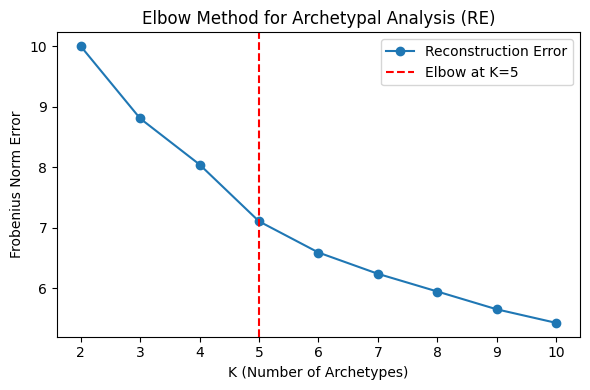

(Info) Elbow RSS menyarankan K=5


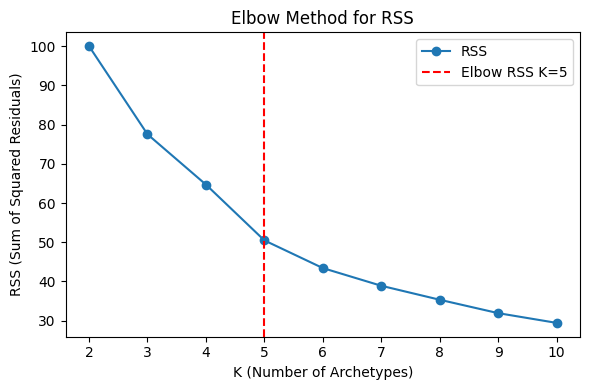

Final metrics for best_K= 5 :
 RE=7.1043, RSS=50.4709, EV=0.686210975612103, SS=0.7823373819715174, MMD=-0.0076801354402002975, LS=0.47575757575757577


/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_mo

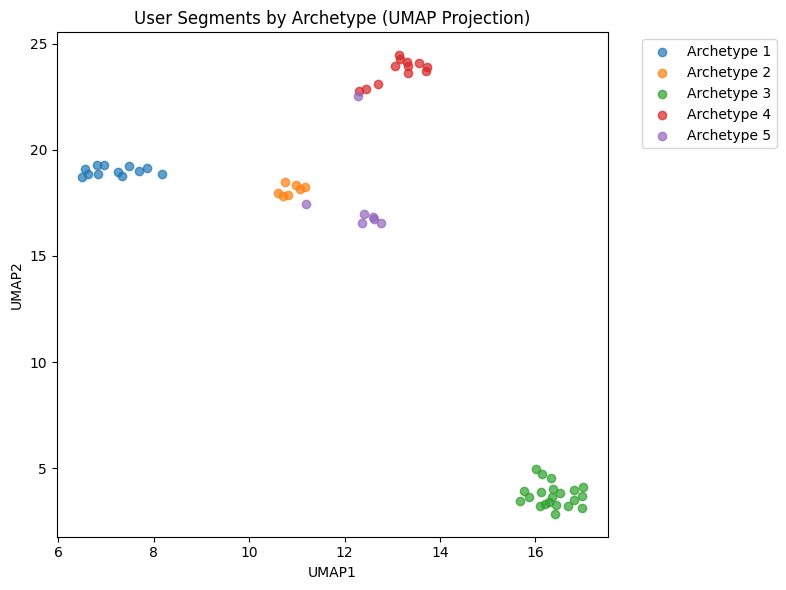

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from scipy.optimize import nnls
from collections import Counter
import matplotlib.pyplot as plt
import umap
from kneed import KneeLocator

# ===================================
# 1) Load & Prepare Data for AA
# ===================================
df_feats = pd.read_csv("user_features_for_AA_v2.csv", dtype={"steam_id": str})
steam_ids = df_feats["steam_id"].tolist()

# Keep basics for later (assume these columns exist)
total_games = df_feats.set_index("steam_id")["total_game"].to_dict()
total_playtime = df_feats.set_index("steam_id")["total_playtime"].to_dict()
total_achievements = df_feats.set_index("steam_id")["total_achievement"].to_dict()

# Build and scale feature matrix X (exclude steam_id)
feature_cols = [c for c in df_feats.columns if c != "steam_id"]
X = df_feats[feature_cols].values
X_scaled = MinMaxScaler().fit_transform(X)

# ===================================
# 2) Load Raw Segmentation & Features
# ===================================
df_raw = pd.read_csv("transformation_segmentation_v4.csv", dtype={"Steam ID": str})
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
df_raw = df_raw[df_raw["steam_id"].isin(steam_ids)]

# map dominant topic if available
if "topic_dominan" in df_raw.columns:
    dominant_topic = df_raw.groupby("steam_id")["topic_dominan"].first().to_dict()
else:
    dominant_topic = {}

tmp = df_raw.groupby("steam_id")["genre_dominan"] \
            .apply(lambda xs: [g for g, _ in Counter(xs).most_common(3)]) if "genre_dominan" in df_raw.columns else pd.Series()
top3_genres = {
    sid: (tmp.get(sid, [])[:3] + [np.nan] * (3 - len(tmp.get(sid, [])))) if sid in tmp.index else [np.nan, np.nan, np.nan]
    for sid in steam_ids
}

# ===================================
# 3) Sensitive attribute detection or proxy creation
# ===================================
# If you have a known sensitive column, set it here, e.g. sensitive_col = "gender"
sensitive_col = None  # <-- set to column name string to force using that column

_possible_names = ['sensitive', 'gender', 'sex', 'group', 'age_group', 'protected', 'race', 'ethnicity', 'dominant_topic']
found = None
if sensitive_col is None:
    for col in df_feats.columns:
        if col.lower() in _possible_names:
            found = col
            break
    if found is None:
        for col in df_raw.columns:
            if col.lower() in _possible_names:
                found = col
                break
    if found:
        sensitive_col = found

# If still None, create a proxy group (median split on total_playtime or total_game, or use dominant_topic)
if sensitive_col is None:
    if "total_playtime" in df_feats.columns:
        df_feats["playtime_median_group"] = (df_feats["total_playtime"] > df_feats["total_playtime"].median()).astype(int).astype(str)
        sensitive_col = "playtime_median_group"
        print("No sensitive column detected: created proxy 'playtime_median_group' (median split).")
    elif "total_game" in df_feats.columns:
        df_feats["total_game_median_group"] = (df_feats["total_game"] > df_feats["total_game"].median()).astype(int).astype(str)
        sensitive_col = "total_game_median_group"
        print("No sensitive column detected: created proxy 'total_game_median_group' (median split).")
    elif "topic_dominan" in df_raw.columns:
        tmp_map = df_raw.set_index("steam_id")["topic_dominan"].to_dict()
        df_feats["dominant_topic_proxy"] = df_feats["steam_id"].map(tmp_map).fillna("unknown").astype(str)
        sensitive_col = "dominant_topic_proxy"
        print("No sensitive column detected: created proxy 'dominant_topic_proxy' from df_raw.")
    else:
        sensitive_col = None
        print("Warning: no sensitive attribute found and no proxy could be created. MMD and LS will be skipped.")

# Build sensitive_array aligned to steam_ids order
if sensitive_col is not None:
    if sensitive_col in df_feats.columns:
        sens_map = df_feats.set_index("steam_id")[sensitive_col].to_dict()
        sensitive_array = np.array([sens_map.get(sid, np.nan) for sid in steam_ids], dtype=object)
    elif sensitive_col in df_raw.columns:
        sens_map = df_raw.set_index("steam_id")[sensitive_col].to_dict()
        sensitive_array = np.array([sens_map.get(sid, np.nan) for sid in steam_ids], dtype=object)
    else:
        sensitive_array = None
else:
    sensitive_array = None

# Print group counts for debugging
if sensitive_array is not None:
    counts = pd.Series(sensitive_array).fillna("nan").value_counts()
    print("Sensitive groups and counts:")
    print(counts)
    small = counts[counts < 2]
    if len(small) > 0:
        print("Warning: some groups have <2 samples (these groups will be ignored for pairwise MMD).")
else:
    print("sensitive_array is None -> MMD and Linear Separability will be skipped.")

# ===================================
# 4) Archetypal Analysis Function
# ====================================
def compute_normed_A(X, K, max_iter=100, tol=1e-4):
    n, d = X.shape
    rng = np.random.RandomState(42)
    Z = X[rng.choice(n, K, replace=(K > n))].copy()  # (K, d)

    for _ in range(max_iter):
        A = np.zeros((n, K))
        for i in range(n):
            # solve Z.T * a = X[i]  => use nnls for non-negative weights
            A[i], _ = nnls(Z.T, X[i])

        Z_new = np.zeros_like(Z)
        for j in range(K):
            w = A[:, j][:, None]  # (n,1)
            if w.sum() > 0:
                Z_new[j] = (w * X).sum(axis=0) / w.sum()
            else:
                Z_new[j] = Z[j]

        if np.linalg.norm(Z - Z_new) < tol:
            break
        Z = Z_new

    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    A_norm = A / row_sums
    return A_norm, Z

# ===================================
# 5) Helper metrics: EV, RSS, MMD, LS
# ====================================
def explained_variance_matrix(X_true, X_recon):
    num = np.sum((X_true - X_recon)**2)
    denom = np.sum((X_true - X_true.mean(axis=0))**2)
    if denom == 0:
        return np.nan
    ev = 1 - (num / denom)
    return float(ev)

# --- NEW: RSS helper ---
def residual_sum_of_squares(X_true, X_recon):
    """Residual Sum of Squares (RSS) = jumlah kuadrat residual."""
    R = X_true - X_recon
    return float(np.sum(R * R))
# --- END NEW ---

def rbf_kernel_matrix(X, Y=None, gamma=None):
    if Y is None:
        Y = X
    XX = np.sum(X**2, axis=1)[:, None]
    YY = np.sum(Y**2, axis=1)[None, :]
    D2 = XX + YY - 2 * np.dot(X, Y.T)
    if gamma is None:
        dists = D2.flatten()
        dists = dists[dists > 0]
        if len(dists) == 0:
            gamma = 1.0
        else:
            med = np.median(dists)
            gamma = 1.0 / (2 * med) if med > 0 else 1.0
    K = np.exp(-gamma * D2)
    return K, gamma

def compute_mmd_rbf(X, Y, gamma=None):
    m = X.shape[0]; n = Y.shape[0]
    if m < 2 or n < 2:
        return np.nan
    Kxx, gamma = rbf_kernel_matrix(X, None, gamma)
    Kyy, _ = rbf_kernel_matrix(Y, None, gamma)
    Kxy, _ = rbf_kernel_matrix(X, Y, gamma)
    sum_kxx = (np.sum(Kxx) - np.trace(Kxx))
    sum_kyy = (np.sum(Kyy) - np.trace(Kyy))
    mmd = (sum_kxx / (m * (m - 1))) + (sum_kyy / (n * (n - 1))) - (2 * np.sum(Kxy) / (m * n))
    return float(mmd)

def average_pairwise_mmd(X_repr, sensitive_array):
    if sensitive_array is None:
        return np.nan
    mask_valid = ~pd.isna(sensitive_array)
    groups, inv = np.unique(sensitive_array[mask_valid], return_inverse=True)
    if len(groups) < 2:
        return np.nan
    mmds = []
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            Xi = X_repr[sensitive_array == groups[i]]
            Xj = X_repr[sensitive_array == groups[j]]
            if Xi.shape[0] < 2 or Xj.shape[0] < 2:
                continue
            m = compute_mmd_rbf(Xi, Xj, gamma=None)
            if not np.isnan(m):
                mmds.append(m)
    if len(mmds) == 0:
        return np.nan
    return float(np.mean(mmds))

def linear_separability_score(X_repr, sensitive_array, cv_folds=5):
    if sensitive_array is None:
        return np.nan
    mask = ~pd.isna(sensitive_array)
    y = sensitive_array[mask]
    Xsub = X_repr[mask]
    unique, counts = np.unique(y, return_counts=True)
    if len(unique) < 2:
        return np.nan
    min_count = np.min(counts)
    # stratified CV only possible if each class has at least 2 samples and n_splits >= 2
    n_splits = min(cv_folds, min_count) if min_count >= 2 else 1
    clf = LogisticRegression(max_iter=1000, multi_class='auto', solver='lbfgs')
    if n_splits >= 2:
        try:
            skf = StratifiedKFold(n_splits=n_splits)
            scores = cross_val_score(clf, Xsub, y, cv=skf, scoring='accuracy')
            return float(np.mean(scores))
        except Exception:
            pass
    # fallback: single train/test split
    try:
        Xtr, Xte, ytr, yte = train_test_split(Xsub, y, test_size=0.3, stratify=y, random_state=42)
        clf.fit(Xtr, ytr)
        acc = clf.score(Xte, yte)
        return float(acc)
    except Exception:
        return np.nan

# ===================================
# 6) Compare K from 2 to 10 and Save Extended Metrics
# ====================================
min_K, max_K = 2, 10
Ks = list(range(min_K, max_K + 1))
errors = []
results = []

for K in Ks:
    print(f"Running AA for K={K} ...")
    A_norm_k, Z_k = compute_normed_A(X_scaled, K)
    X_recon = A_norm_k.dot(Z_k)
    re_error = float(np.linalg.norm(X_scaled - X_recon, 'fro'))

    # --- NEW: RSS per K ---
    rss_k = residual_sum_of_squares(X_scaled, X_recon)
    # --- END NEW ---

    errors.append(re_error)
    try:
        labels = np.argmax(A_norm_k, axis=1)
        sil_score = float(silhouette_score(A_norm_k, labels))
    except Exception:
        sil_score = np.nan

    ev = explained_variance_matrix(X_scaled, X_recon)
    mmd_val = average_pairwise_mmd(A_norm_k, sensitive_array) if sensitive_array is not None else np.nan
    ls_val = linear_separability_score(A_norm_k, sensitive_array, cv_folds=5) if sensitive_array is not None else np.nan

    results.append({
        "K": K,
        "Reconstruction_Error": re_error,
        "RSS": rss_k,                        # <-- NEW
        "Silhouette_Score": sil_score,
        "Explained_Variance": ev,
        "MMD": mmd_val,
        "Linear_Separability": ls_val
    })
    print(f"K={K}: RE={re_error:.4f}, RSS={rss_k:.4f}, SS={sil_score}, EV={ev}, MMD={mmd_val}, LS={ls_val}")

# Save extended comparison
df_results = pd.DataFrame(results)
df_results.to_csv("aa_k_comparison_RSS.csv", index=False)
print("Perbandingan K tersimpan di aa_k_comparison_RSS.csv")

# ===================================
# 7) Determine best_K via Elbow Method (RE) + (Info) Elbow RSS
# ====================================
kl = KneeLocator(Ks, [r["Reconstruction_Error"] for r in results], curve='convex', direction='decreasing')
best_K = kl.elbow or Ks[np.argmin([r["Reconstruction_Error"] for r in results])]
print(f"Selected best K (by RE elbow/min): {best_K}")

plt.figure(figsize=(6,4))
plt.plot(Ks, [r["Reconstruction_Error"] for r in results], 'o-', label='Reconstruction Error')
if kl.elbow:
    plt.axvline(kl.elbow, color='red', linestyle='--', label=f'Elbow at K={kl.elbow}')
plt.xlabel('K (Number of Archetypes)')
plt.ylabel('Frobenius Norm Error')
plt.title('Elbow Method for Archetypal Analysis (RE)')
plt.legend()
plt.tight_layout()
plt.show()

# --- NEW: Elbow untuk RSS (informasi saja) ---
kl_rss = KneeLocator(Ks, [r["RSS"] for r in results], curve='convex', direction='decreasing')
best_K_rss = kl_rss.elbow or Ks[np.argmin([r["RSS"] for r in results])]
print(f"(Info) Elbow RSS menyarankan K={best_K_rss}")

plt.figure(figsize=(6,4))
plt.plot(Ks, [r["RSS"] for r in results], 'o-', label='RSS')
if kl_rss.elbow:
    plt.axvline(kl_rss.elbow, color='red', linestyle='--', label=f'Elbow RSS K={kl_rss.elbow}')
plt.xlabel('K (Number of Archetypes)')
plt.ylabel('RSS (Sum of Squared Residuals)')
plt.title('Elbow Method for RSS')
plt.legend()
plt.tight_layout()
plt.show()
# --- END NEW ---

# ===================================
# 8) Compute Final AA with Best K and Save Outputs
# ====================================
A_norm, Z = compute_normed_A(X_scaled, best_K)

# final metrics
X_recon_final = A_norm.dot(Z)
re_final = float(np.linalg.norm(X_scaled - X_recon_final, 'fro'))
ev_final = explained_variance_matrix(X_scaled, X_recon_final)
# --- NEW: RSS final ---
rss_final = residual_sum_of_squares(X_scaled, X_recon_final)
# --- END NEW ---
try:
    sil_final = float(silhouette_score(A_norm, np.argmax(A_norm, axis=1)))
except Exception:
    sil_final = np.nan
mmd_final = average_pairwise_mmd(A_norm, sensitive_array) if sensitive_array is not None else np.nan
ls_final = linear_separability_score(A_norm, sensitive_array) if sensitive_array is not None else np.nan

print("Final metrics for best_K=", best_K, ":")
print(f" RE={re_final:.4f}, RSS={rss_final:.4f}, EV={ev_final}, SS={sil_final}, MMD={mmd_final}, LS={ls_final}")

# Save archetype membership (dominant only)
dominant_archetypes = np.argmax(A_norm, axis=1) + 1  # 1-based
dominant_membership = {f"archetype_{k+1}": [] for k in range(best_K)}
for sid, arc in zip(steam_ids, dominant_archetypes):
    dominant_membership[f"archetype_{arc}"].append(sid)

max_len = max(len(v) for v in dominant_membership.values())
for k in dominant_membership:
    dominant_membership[k] += [np.nan] * (max_len - len(dominant_membership[k]))
pd.DataFrame(dominant_membership).to_csv("archetype_membership_RSS.csv", index=False)

# Save per-user segmentation with archetype weights
rows = []
for idx, sid in enumerate(steam_ids):
    t1, t2, t3 = top3_genres.get(sid, [np.nan, np.nan, np.nan])
    row = {
        "steam_id": sid,
        "total_game": total_games.get(sid, np.nan),
        "total_playtime": total_playtime.get(sid, np.nan),
        "total_achievement": total_achievements.get(sid, np.nan),
        "dominant_topic": dominant_topic.get(sid, np.nan),
        "top_1_genre": t1,
        "top_2_genre": t2,
        "top_3_genre": t3
    }
    for k in range(best_K):
        row[f"archetype_{k+1}_weight"] = A_norm[idx, k]
    rows.append(row)
pd.DataFrame(rows).to_csv("archetypal_segments_elbowK_RSS.csv", index=False)

# UMAP visualization
reducer = umap.UMAP(n_components=2, random_state=42)
coords_umap = reducer.fit_transform(A_norm)
dominant_arc = np.argmax(A_norm, axis=1) + 1

plt.figure(figsize=(8,6))
for k in range(1, best_K + 1):
    mask = dominant_arc == k
    plt.scatter(coords_umap[mask, 0], coords_umap[mask, 1], label=f"Archetype {k}", alpha=0.7)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("User Segments by Archetype (UMAP Projection)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd

# simpan Matriks B
df_B = pd.DataFrame(A_norm, columns=[f"Arketipe_{i+1}" for i in range(5)])
df_B.insert(0, "steam_id", steam_ids)
df_B.to_csv("Matriks_B.csv", index=False)

# simpan Matriks Z
df_Z = pd.DataFrame(Z, columns=feature_cols)
df_Z.insert(0, "Arketipe", [f"Arketipe_{i+1}" for i in range(5)])
df_Z.to_csv("Matriks_Z.csv", index=False)


In [1]:
import pandas as pd

# Baca dataset
df = pd.read_csv("combined_dataset.csv")

# Buang kolom "Unnamed" yang tidak dipakai
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Buat data baru dengan Steam ID unik
# Misalnya kita ambil:
# - total game yang dimiliki
# - total playtime
# - rata-rata playtime
# - total achievements
# - genre dominan (paling sering muncul)

# Hitung total game per Steam ID
games_count = df.groupby("Steam ID")["App ID"].nunique()

# Hitung total & rata-rata playtime
playtime_sum = df.groupby("Steam ID")["Playtime (hours)"].sum()
playtime_mean = df.groupby("Steam ID")["Playtime (hours)"].mean()

# Hitung total achievements
achievements_sum = df.groupby("Steam ID")["Achievements"].sum()

# Ambil genre dominan (mode)
dominant_genre = df.groupby("Steam ID")["Genres"].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

# Gabungkan semua hasil ke dataframe baru
final_df = pd.DataFrame({
    "Total_Games": games_count,
    "Total_Playtime": playtime_sum,
    "Avg_Playtime": playtime_mean,
    "Total_Achievements": achievements_sum,
    "Dominant_Genre": dominant_genre
}).reset_index()

# Simpan hasil ke CSV baru
final_df.to_csv("unique_steam_users.csv", index=False)

print("Dataset baru dengan Steam ID unik sudah dibuat -> unique_steam_users.csv")


/var/folders/kh/7d1scz1n2f7gnm2sy2q4rgs00000gn/T/ipykernel_4035/3051713677.py:4: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("combined_dataset.csv")


Dataset baru dengan Steam ID unik sudah dibuat -> unique_steam_users.csv


In [11]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from scipy.optimize import nnls
from collections import Counter
import matplotlib.pyplot as plt
import umap
from kneed import KneeLocator

# ---------------------------
# Konfigurasi
# ---------------------------
INPUT_FEATURES_CSV = "user_features_for_AA_v2.csv"
INPUT_RAW_CSV = "transformation_segmentation_v4.csv"
OUT_DIR = "aa_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

MIN_K = 2
MAX_K = 10
MAX_ITER = 200
TOL = 1e-4
RANDOM_SEED = 42
FORCE_K = None   # <-- jika ingin paksa 5, set ke 5; kalau None maka gunakan elbow

np.random.seed(RANDOM_SEED)

# ===================================
# 1) Load & Prepare Data for AA
# ===================================
df_feats = pd.read_csv(INPUT_FEATURES_CSV, dtype={"steam_id": str})
steam_ids = df_feats["steam_id"].tolist()

# Keep basics for later (asumsi kolom ada)
total_games = df_feats.set_index("steam_id").get("total_game", pd.Series(dtype=float)).to_dict()
total_playtime = df_feats.set_index("steam_id").get("total_playtime", pd.Series(dtype=float)).to_dict()
total_achievements = df_feats.set_index("steam_id").get("total_achievement", pd.Series(dtype=float)).to_dict()

# Build and scale feature matrix X (exclude steam_id)
feature_cols = [c for c in df_feats.columns if c != "steam_id"]
if len(feature_cols) == 0:
    raise ValueError("Tidak ditemukan fitur (kecuali steam_id). Periksa file input.")
X = df_feats[feature_cols].values.astype(float)
X_scaled = MinMaxScaler().fit_transform(X)

# ===================================
# 2) Load Raw Segmentation & Features
# ===================================
try:
    df_raw = pd.read_csv(INPUT_RAW_CSV, dtype=str)
    df_raw.columns = (
        df_raw.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
    )
except Exception:
    df_raw = pd.DataFrame()

# jika kolom steam_id ada
if "steam_id" not in df_raw.columns and "steam id" in df_raw.columns:
    df_raw = df_raw.rename(columns={"steam id":"steam_id"})

df_raw = df_raw[df_raw["steam_id"].isin(steam_ids)] if "steam_id" in df_raw.columns else df_raw

# map dominant topic if available
if "topic_dominan" in df_raw.columns:
    dominant_topic = df_raw.groupby("steam_id")["topic_dominan"].first().to_dict()
else:
    dominant_topic = {}

# top3 genres
if "genre_dominan" in df_raw.columns:
    tmp = df_raw.groupby("steam_id")["genre_dominan"] \
                .apply(lambda xs: [g for g, _ in Counter(xs).most_common(3)])
    top3_genres = {
        sid: (tmp.get(sid, [])[:3] + [np.nan] * (3 - len(tmp.get(sid, [])))) if sid in tmp.index else [np.nan, np.nan, np.nan]
        for sid in steam_ids
    }
else:
    top3_genres = {sid: [np.nan, np.nan, np.nan] for sid in steam_ids}

# ===================================
# 3) Sensitive attribute detection or proxy creation
# ===================================
sensitive_col = None  # set nama kolom jika Anda punya (misal "gender")

_possible_names = ['sensitive', 'gender', 'sex', 'group', 'age_group', 'protected', 'race', 'ethnicity', 'dominant_topic']
found = None
if sensitive_col is None:
    for col in df_feats.columns:
        if col.lower() in _possible_names:
            found = col
            break
    if found is None:
        for col in df_raw.columns:
            if col.lower() in _possible_names:
                found = col
                break
    if found:
        sensitive_col = found

if sensitive_col is None:
    if "total_playtime" in df_feats.columns:
        df_feats["playtime_median_group"] = (df_feats["total_playtime"].astype(float) > df_feats["total_playtime"].astype(float).median()).astype(int).astype(str)
        sensitive_col = "playtime_median_group"
        print("No sensitive column detected: created proxy 'playtime_median_group' (median split).")
    elif "total_game" in df_feats.columns:
        df_feats["total_game_median_group"] = (df_feats["total_game"].astype(float) > df_feats["total_game"].astype(float).median()).astype(int).astype(str)
        sensitive_col = "total_game_median_group"
        print("No sensitive column detected: created proxy 'total_game_median_group' (median split).")
    elif "topic_dominan" in df_raw.columns:
        tmp_map = df_raw.set_index("steam_id")["topic_dominan"].to_dict()
        df_feats["dominant_topic_proxy"] = df_feats["steam_id"].map(tmp_map).fillna("unknown").astype(str)
        sensitive_col = "dominant_topic_proxy"
        print("No sensitive column detected: created proxy 'dominant_topic_proxy' from df_raw.")
    else:
        sensitive_col = None
        print("Warning: no sensitive attribute found and no proxy could be created. MMD and LS will be skipped.")

# Build sensitive_array aligned to steam_ids order
if sensitive_col is not None:
    if sensitive_col in df_feats.columns:
        sens_map = df_feats.set_index("steam_id")[sensitive_col].to_dict()
        sensitive_array = np.array([sens_map.get(sid, np.nan) for sid in steam_ids], dtype=object)
    elif sensitive_col in df_raw.columns:
        sens_map = df_raw.set_index("steam_id")[sensitive_col].to_dict()
        sensitive_array = np.array([sens_map.get(sid, np.nan) for sid in steam_ids], dtype=object)
    else:
        sensitive_array = None
else:
    sensitive_array = None

if sensitive_array is not None:
    counts = pd.Series(sensitive_array).fillna("nan").value_counts()
    print("Sensitive groups and counts:\n", counts)
    small = counts[counts < 2]
    if len(small) > 0:
        print("Warning: some groups have <2 samples (these groups will be ignored for pairwise MMD).")
else:
    print("sensitive_array is None -> MMD and Linear Separability will be skipped.")

# ===================================
# 4) Archetypal Analysis Function (dengan logging iterasi) -- MODIFIED to store raw A
# ====================================
def compute_normed_A_with_log(X, K, max_iter=100, tol=1e-4, random_state=42):
    """
    Mengembalikan:
      A_norm_final, Z_final, info_history
    info_history berisi:
      - 'n_iter' : jumlah iterasi yang dilakukan
      - 'A_iter1', 'Z_iter1' : Matriks A_norm & Z pada iterasi 1
      - 'A_raw_iter1' : Matriks A (raw) pada iterasi 1 (sebelum normalisasi)
      - 'A_final', 'Z_final' : Matriks A_norm & Z pada iterasi final
      - 'A_raw_final' : Matriks A (raw) pada iterasi final
    """
    n, d = X.shape
    rng = np.random.RandomState(random_state)
    # inisialisasi Z sebagai K sampel acak dari X
    Z = X[rng.choice(n, K, replace=(K > n))].astype(float).copy()  # shape (K, d)

    history = {}
    for it in range(1, max_iter + 1):
        A = np.zeros((n, K), dtype=float)   # raw A (non-normalized)
        # solve non-negative least squares per baris -> isi A
        for i in range(n):
            A[i], _ = nnls(Z.T, X[i])

        # update Z berdasarkan A
        Z_new = np.zeros_like(Z)
        for j in range(K):
            w = A[:, j][:, None]  # shape (n,1)
            if w.sum() > 0:
                Z_new[j] = (w * X).sum(axis=0) / float(w.sum())
            else:
                Z_new[j] = Z[j]

        # normalisasi baris A -> A_norm_tmp (sementara) untuk disimpan pada iter 1
        row_sums = A.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        A_norm_tmp = A / row_sums

        if it == 1:
            # simpan iterasi 1 (A_norm dan Z saat itu) dan juga A raw
            history["A_iter1"] = A_norm_tmp.copy()
            history["Z_iter1"] = Z.copy()
            history["A_raw_iter1"] = A.copy()

        # cek konvergensi
        if np.linalg.norm(Z - Z_new) < tol:
            # simpan final (iterasi it): normalisasi final + raw A
            row_sums = A.sum(axis=1, keepdims=True)
            row_sums[row_sums == 0] = 1.0
            A_norm_final = A / row_sums
            history["n_iter"] = it
            history["A_final"] = A_norm_final.copy()
            history["Z_final"] = Z_new.copy()
            history["A_raw_final"] = A.copy()
            return A_norm_final, Z_new, history

        Z = Z_new

    # jika tidak konvergen sampai max_iter, kembalikan keadaan terakhir (sama simpan raw A terakhir)
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    A_norm_final = A / row_sums
    history["n_iter"] = max_iter
    history["A_final"] = A_norm_final.copy()
    history["Z_final"] = Z.copy()
    history["A_raw_final"] = A.copy()
    return A_norm_final, Z, history

# ===================================
# 5) Helper metrics: EV, RSS, MMD, LS
# ====================================
def explained_variance_matrix(X_true, X_recon):
    num = np.sum((X_true - X_recon)**2)
    denom = np.sum((X_true - X_true.mean(axis=0))**2)
    if denom == 0:
        return np.nan
    ev = 1 - (num / denom)
    return float(ev)

def residual_sum_of_squares(X_true, X_recon):
    R = X_true - X_recon
    return float(np.sum(R * R))

def rbf_kernel_matrix(X, Y=None, gamma=None):
    if Y is None:
        Y = X
    XX = np.sum(X**2, axis=1)[:, None]
    YY = np.sum(Y**2, axis=1)[None, :]
    D2 = XX + YY - 2 * np.dot(X, Y.T)
    if gamma is None:
        dists = D2.flatten()
        dists = dists[dists > 0]
        if len(dists) == 0:
            gamma = 1.0
        else:
            med = np.median(dists)
            gamma = 1.0 / (2 * med) if med > 0 else 1.0
    Kmat = np.exp(-gamma * D2)
    return Kmat, gamma

def compute_mmd_rbf(X, Y, gamma=None):
    m = X.shape[0]; n = Y.shape[0]
    if m < 2 or n < 2:
        return np.nan
    Kxx, gamma = rbf_kernel_matrix(X, None, gamma)
    Kyy, _ = rbf_kernel_matrix(Y, None, gamma)
    Kxy, _ = rbf_kernel_matrix(X, Y, gamma)
    sum_kxx = (np.sum(Kxx) - np.trace(Kxx))
    sum_kyy = (np.sum(Kyy) - np.trace(Kyy))
    mmd = (sum_kxx / (m * (m - 1))) + (sum_kyy / (n * (n - 1))) - (2 * np.sum(Kxy) / (m * n))
    return float(mmd)

def average_pairwise_mmd(X_repr, sensitive_array):
    if sensitive_array is None:
        return np.nan
    mask_valid = ~pd.isna(sensitive_array)
    groups, inv = np.unique(sensitive_array[mask_valid], return_inverse=True)
    if len(groups) < 2:
        return np.nan
    mmds = []
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            Xi = X_repr[sensitive_array == groups[i]]
            Xj = X_repr[sensitive_array == groups[j]]
            if Xi.shape[0] < 2 or Xj.shape[0] < 2:
                continue
            m = compute_mmd_rbf(Xi, Xj, gamma=None)
            if not np.isnan(m):
                mmds.append(m)
    if len(mmds) == 0:
        return np.nan
    return float(np.mean(mmds))

def linear_separability_score(X_repr, sensitive_array, cv_folds=5):
    if sensitive_array is None:
        return np.nan
    mask = ~pd.isna(sensitive_array)
    y = sensitive_array[mask]
    Xsub = X_repr[mask]
    unique, counts = np.unique(y, return_counts=True)
    if len(unique) < 2:
        return np.nan
    min_count = np.min(counts)
    n_splits = min(cv_folds, min_count) if min_count >= 2 else 1
    clf = LogisticRegression(max_iter=1000, multi_class='auto', solver='lbfgs')
    if n_splits >= 2:
        try:
            skf = StratifiedKFold(n_splits=n_splits)
            scores = cross_val_score(clf, Xsub, y, cv=skf, scoring='accuracy')
            return float(np.mean(scores))
        except Exception:
            pass
    try:
        Xtr, Xte, ytr, yte = train_test_split(Xsub, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)
        clf.fit(Xtr, ytr)
        acc = clf.score(Xte, yte)
        return float(acc)
    except Exception:
        return np.nan

# ===================================
# 6) Compare K from MIN_K to MAX_K and Save Extended Metrics
# ====================================
Ks = list(range(MIN_K, MAX_K + 1))
results = []
errors = []

for K in Ks:
    print(f"\nRunning AA for K={K} ...")
    A_norm_k, Z_k, hist_k = compute_normed_A_with_log(X_scaled, K, max_iter=MAX_ITER, tol=TOL, random_state=RANDOM_SEED)
    X_recon = A_norm_k.dot(Z_k)
    re_error = float(np.linalg.norm(X_scaled - X_recon, 'fro'))
    rss_k = residual_sum_of_squares(X_scaled, X_recon)

    try:
        labels = np.argmax(A_norm_k, axis=1)
        sil_score = float(silhouette_score(A_norm_k, labels))
    except Exception:
        sil_score = np.nan

    ev = explained_variance_matrix(X_scaled, X_recon)
    mmd_val = average_pairwise_mmd(A_norm_k, sensitive_array) if sensitive_array is not None else np.nan
    ls_val = linear_separability_score(A_norm_k, sensitive_array, cv_folds=5) if sensitive_array is not None else np.nan

    results.append({
        "K": K,
        "Reconstruction_Error": re_error,
        "RSS": rss_k,
        "Silhouette_Score": sil_score,
        "Explained_Variance": ev,
        "MMD": mmd_val,
        "Linear_Separability": ls_val,
        "n_iter": hist_k.get("n_iter", np.nan)
    })
    errors.append(re_error)
    print(f"K={K}: RE={re_error:.6f}, RSS={rss_k:.6f}, SS={sil_score}, EV={ev}, MMD={mmd_val}, LS={ls_val}, n_iter={hist_k.get('n_iter')}")

# Save extended comparison
df_results = pd.DataFrame(results)
df_results.to_csv(os.path.join(OUT_DIR, "aa_k_comparison_RSS.csv"), index=False)
print(f"\nPerbandingan K tersimpan di {os.path.join(OUT_DIR, 'aa_k_comparison_RSS.csv')}")

# ===================================
# 7) Determine best_K via Elbow Method (RE) + Info from RSS
# ====================================
if FORCE_K is not None:
    best_K = int(FORCE_K)
    print(f"FORCE_K is set -> using K={best_K}")
else:
    kl = KneeLocator(Ks, df_results["Reconstruction_Error"].tolist(), curve='convex', direction='decreasing')
    best_K = int(kl.elbow) if kl.elbow else int(Ks[np.argmin(df_results["Reconstruction_Error"].values)])
    print(f"Selected best K (by RE elbow/min): {best_K}")

# Info elbow RSS (sekedar informasi)
kl_rss = KneeLocator(Ks, df_results["RSS"].tolist(), curve='convex', direction='decreasing')
best_K_rss = int(kl_rss.elbow) if kl_rss.elbow else int(Ks[np.argmin(df_results["RSS"].values)])
print(f"(Info) Elbow RSS menyarankan K={best_K_rss}")

# optional: simpan plots (png)
try:
    plt.figure(figsize=(6,4))
    plt.plot(Ks, df_results["Reconstruction_Error"].values, 'o-', label='Reconstruction Error')
    if 'kl' in locals() and kl.elbow:
        plt.axvline(kl.elbow, color='red', linestyle='--', label=f'Elbow at K={kl.elbow}')
    plt.xlabel('K (Number of Archetypes)')
    plt.ylabel('Frobenius Norm Error')
    plt.title('Elbow Method for Archetypal Analysis (RE)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "elbow_re.png"), dpi=150)
    plt.close()

    plt.figure(figsize=(6,4)
)
    plt.plot(Ks, df_results["RSS"].values, 'o-', label='RSS')
    if kl_rss.elbow:
        plt.axvline(kl_rss.elbow, color='red', linestyle='--', label=f'Elbow RSS K={kl_rss.elbow}')
    plt.xlabel('K (Number of Archetypes)')
    plt.ylabel('RSS (Sum of Squared Residuals)')
    plt.title('Elbow Method for RSS')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "elbow_rss.png"), dpi=150)
    plt.close()
except Exception as e:
    print("Gagal menyimpan plot elbow:", e)

# ===================================
# 8) Compute Final AA with best_K and Save Outputs (termasuk iter1 & final)
# ====================================
A_norm, Z, history = compute_normed_A_with_log(X_scaled, best_K, max_iter=MAX_ITER, tol=TOL, random_state=RANDOM_SEED)

# ambil data iter1 & final dari history (jika ada)
A_iter1 = history.get("A_iter1")
Z_iter1 = history.get("Z_iter1")
A_raw_iter1 = history.get("A_raw_iter1")
n_iter_done = history.get("n_iter", np.nan)
A_final = history.get("A_final")
Z_final = history.get("Z_final")
A_raw_final = history.get("A_raw_final")

# final metrics
X_recon_final = A_norm.dot(Z)
re_final = float(np.linalg.norm(X_scaled - X_recon_final, 'fro'))
rss_final = residual_sum_of_squares(X_scaled, X_recon_final)
try:
    sil_final = float(silhouette_score(A_norm, np.argmax(A_norm, axis=1)))
except Exception:
    sil_final = np.nan
ev_final = explained_variance_matrix(X_scaled, X_recon_final)
mmd_final = average_pairwise_mmd(A_norm, sensitive_array) if sensitive_array is not None else np.nan
ls_final = linear_separability_score(A_norm, sensitive_array) if sensitive_array is not None else np.nan

print("\nFinal metrics for best_K=", best_K, ":")
print(f" n_iter={n_iter_done}, RE={re_final:.6f}, RSS={rss_final:.6f}, EV={ev_final}, SS={sil_final}, MMD={mmd_final}, LS={ls_final}")

# ----------------------------
# Simpan Matriks B (A_norm) dan Z iterasi 1 (jika ada) & raw A iterasi 1
# ----------------------------
def save_matrix_BZ(A_matrix, Z_matrix, prefix):
    # A_matrix: n x K, Z_matrix: K x d
    if A_matrix is None or Z_matrix is None:
        return
    dfA = pd.DataFrame(A_matrix, columns=[f"archetype_{i+1}" for i in range(A_matrix.shape[1])])
    dfA.insert(0, "steam_id", steam_ids)
    dfA.to_csv(os.path.join(OUT_DIR, f"{prefix}_MatriksB.csv"), index=False)

    dfZ = pd.DataFrame(Z_matrix, columns=feature_cols)
    dfZ.insert(0, "archetype", [f"archetype_{i+1}" for i in range(Z_matrix.shape[0])])
    dfZ.to_csv(os.path.join(OUT_DIR, f"{prefix}_MatriksZ.csv"), index=False)

# save iter1 normalized & raw
if A_iter1 is not None and Z_iter1 is not None:
    save_matrix_BZ(A_iter1, Z_iter1, "iter1")
    # raw A iter1
    if A_raw_iter1 is not None:
        dfAraw1 = pd.DataFrame(A_raw_iter1, columns=[f"archetype_{i+1}" for i in range(A_raw_iter1.shape[1])])
        dfAraw1.insert(0, "steam_id", steam_ids)
        dfAraw1.to_csv(os.path.join(OUT_DIR, "iter1_MatriksA_raw.csv"), index=False)

# save final normalized & raw
save_matrix_BZ(A_final, Z_final, "final")
if A_raw_final is not None:
    dfArawf = pd.DataFrame(A_raw_final, columns=[f"archetype_{i+1}" for i in range(A_raw_final.shape[1])])
    dfArawf.insert(0, "steam_id", steam_ids)
    dfArawf.to_csv(os.path.join(OUT_DIR, "final_MatriksA_raw.csv"), index=False)

# juga simpan Matriks B final sesuai variable A_norm
save_matrix_BZ(A_norm, Z, "A_norm_final")

# ----------------------------
# Simpan hasil per-user dengan bobot arketipe
# ----------------------------
rows = []
for idx, sid in enumerate(steam_ids):
    t1, t2, t3 = top3_genres.get(sid, [np.nan, np.nan, np.nan])
    row = {
        "steam_id": sid,
        "total_game": total_games.get(sid, np.nan),
        "total_playtime": total_playtime.get(sid, np.nan),
        "total_achievement": total_achievements.get(sid, np.nan),
        "dominant_topic": dominant_topic.get(sid, np.nan),
        "top_1_genre": t1,
        "top_2_genre": t2,
        "top_3_genre": t3
    }
    for k in range(A_norm.shape[1]):
        row[f"archetype_{k+1}_weight"] = float(A_norm[idx, k])
    rows.append(row)
pd.DataFrame(rows).to_csv(os.path.join(OUT_DIR, "archetypal_segments_elbowK_RSS.csv"), index=False)
print("Per-user archetype weights disimpan di:", os.path.join(OUT_DIR, "archetypal_segments_elbowK_RSS.csv"))

# Save archetype membership (dominant only)
dominant_archetypes = np.argmax(A_norm, axis=1) + 1  # 1-based
dominant_membership = {f"archetype_{k+1}": [] for k in range(A_norm.shape[1])}
for sid, arc in zip(steam_ids, dominant_archetypes):
    dominant_membership[f"archetype_{arc}"].append(sid)
max_len = max(len(v) for v in dominant_membership.values())
for k in dominant_membership:
    dominant_membership[k] += [np.nan] * (max_len - len(dominant_membership[k]))
pd.DataFrame(dominant_membership).to_csv(os.path.join(OUT_DIR, "archetype_membership_RSS.csv"), index=False)
print("Archetype membership disimpan di:", os.path.join(OUT_DIR, "archetype_membership_RSS.csv"))

# Save summary metrics
summary = {
    "best_K": best_K,
    "best_K_rss_suggestion": best_K_rss,
    "n_iter_final": n_iter_done,
    "RE_final": re_final,
    "RSS_final": rss_final,
    "EV_final": ev_final,
    "SS_final": sil_final,
    "MMD_final": mmd_final,
    "LS_final": ls_final
}
pd.DataFrame([summary]).to_csv(os.path.join(OUT_DIR, "aa_summary_final_metrics.csv"), index=False)
print("Ringkasan final disimpan di:", os.path.join(OUT_DIR, "aa_summary_final_metrics.csv"))

# ===================================
# 9) UMAP visualization (2D) & simpan
# ====================================
try:
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_SEED)
    coords_umap = reducer.fit_transform(A_norm)
    dominant_arc = np.argmax(A_norm, axis=1) + 1

    plt.figure(figsize=(8,6))
    for k in range(1, A_norm.shape[1] + 1):
        mask = dominant_arc == k
        plt.scatter(coords_umap[mask, 0], coords_umap[mask, 1], label=f"Archetype {k}", alpha=0.7)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title(f"User Segments by Archetype (UMAP) - K={best_K}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"umap_archetypes_k{best_K}.png"), dpi=200)
    plt.close()
    print("UMAP saved:", os.path.join(OUT_DIR, f"umap_archetypes_k{best_K}.png"))
except Exception as e:
    print("Gagal membuat UMAP:", e)

print("\nSelesai. Semua output ada di folder:", OUT_DIR)


No sensitive column detected: created proxy 'playtime_median_group' (median split).
Sensitive groups and counts:
 0    30
1    29
Name: count, dtype: int64

Running AA for K=2 ...
K=2: RE=9.999048, RSS=99.980960, SS=0.8720403294225343, EV=0.3783961809788563, MMD=-0.010827860401344758, LS=0.5287878787878787, n_iter=12

Running AA for K=3 ...
K=3: RE=8.804672, RSS=77.522242, SS=0.8085542983651669, EV=0.5180270161370932, MMD=-0.01079367287666999, LS=0.4242424242424242, n_iter=20

Running AA for K=4 ...
K=4: RE=8.043235, RSS=64.693622, SS=0.8034821294262277, EV=0.597785394727713, MMD=-0.014590567249195496, LS=0.4590909090909091, n_iter=20

Running AA for K=5 ...
K=5: RE=7.104292, RSS=50.470970, SS=0.7823373819715174, EV=0.6862107761424001, MMD=-0.0076801354402002975, LS=0.47575757575757577, n_iter=21

Running AA for K=6 ...
K=6: RE=6.588823, RSS=43.412584, SS=0.6959246934888896, EV=0.7300943301570358, MMD=-0.002284623225333071, LS=0.5954545454545455, n_iter=35

Running AA for K=7 ...
K=7: 

/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_mo

K=10: RE=5.425953, RSS=29.440968, SS=0.7124913087491589, EV=0.816958964964468, MMD=0.029316301981847204, LS=0.7318181818181817, n_iter=60

Perbandingan K tersimpan di aa_outputs/aa_k_comparison_RSS.csv
Selected best K (by RE elbow/min): 5
(Info) Elbow RSS menyarankan K=5


/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/sklearn/linear_mo


Final metrics for best_K= 5 :
 n_iter=21, RE=7.104292, RSS=50.470970, EV=0.6862107761424001, SS=0.7823373819715174, MMD=-0.0076801354402002975, LS=0.47575757575757577
Per-user archetype weights disimpan di: aa_outputs/archetypal_segments_elbowK_RSS.csv
Archetype membership disimpan di: aa_outputs/archetype_membership_RSS.csv
Ringkasan final disimpan di: aa_outputs/aa_summary_final_metrics.csv
UMAP saved: aa_outputs/umap_archetypes_k5.png

Selesai. Semua output ada di folder: aa_outputs


In [7]:
# ===================================
# 6) Hitung Mean & Standar Deviasi untuk Standarisasi Z-Score
# ===================================
stats = []
for col in feature_cols:
    mu = df_feats[col].mean()
    sigma = df_feats[col].std(ddof=0)  # pakai populasi (sesuai rumus manual)
    stats.append({
        "feature": col,
        "mean": mu,
        "std_dev": sigma
    })

df_stats = pd.DataFrame(stats)
df_stats.to_csv("Feature_Mean_Std.csv", index=False)

print("File hasil perhitungan mean & standar deviasi disimpan: Feature_Mean_Std.csv")


File hasil perhitungan mean & standar deviasi disimpan: Feature_Mean_Std.csv
